# Notebook 03 — ETA Model Training
**Input:** `data/processed/train_features.csv`, `data/processed/test_features.csv`
**Output:** `models/eta_rf.joblib`, `models/eta_lr.joblib`, `models/eta_quantile.joblib`, `models/eta_gbr.joblib`

Models: Linear Regression (baseline) · Random Forest · Gradient Boosting · Quantile Regression (p10/p50/p90)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, os
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)
sns.set_theme(style='whitegrid')
print('Ready')


Ready


---
## 1. Load Feature Matrices


In [3]:
meta     = joblib.load('models/feature_pipeline.joblib')
FEATURES = meta['features']
TARGET   = meta['target']
train = pd.read_csv('../data/processed/train_features.csv', parse_dates=['order_time'])
test  = pd.read_csv('../data/processed/test_features.csv',  parse_dates=['order_time'])
X_train = train[FEATURES].values; y_train = train[TARGET].values
X_test  = test[FEATURES].values;  y_test  = test[TARGET].values
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Target: mean={y_train.mean():.2f}  std={y_train.std():.2f}  min={y_train.min():.2f}  max={y_train.max():.2f}')


Train: (7428976, 19)  Test: (1857244, 19)
Target: mean=22.54  std=13.64  min=3.00  max=162.54


In [4]:
results = []
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true,1,None))) * 100
    print(f'{name:<30}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}  MAPE={mape:.1f}%')
    results.append({'Model':name,'MAE':round(mae,3),'RMSE':round(rmse,3),'R2':round(r2,3),'MAPE':round(mape,2)})


---
## 2. Baseline — Linear Regression


In [7]:
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)
lr = LinearRegression()
lr.fit(X_tr_s, y_train)
y_pred_lr = lr.predict(X_te_s)
evaluate('LinearRegression (baseline)', y_test, y_pred_lr)
joblib.dump({'model':lr,'scaler':scaler,'features':FEATURES},'models/eta_lr.joblib')
print('Saved → models/eta_lr.joblib')


LinearRegression (baseline)     MAE=5.73  RMSE=8.10  R²=0.680  MAPE=30.0%
Saved → models/eta_lr.joblib


---
## 3. Random Forest


In [12]:
import numpy as np

idx = np.random.default_rng(42).choice(len(X_train), size=500_000, replace=False)

# Use numpy indexing, not iloc
train_sample = X_train[idx]
y_train_sample = y_train[idx]

rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=8,
    min_samples_leaf=100,
    n_jobs=2,
    random_state=42
)

rf.fit(train_sample, y_train_sample)
y_pred_rf = rf.predict(X_test)
evaluate('RandomForest', y_test, y_pred_rf)
joblib.dump({'model': rf, 'features': FEATURES}, 'models/eta_rf.joblib')
print('Saved → models/eta_rf.joblib')

RandomForest                    MAE=5.23  RMSE=7.45  R²=0.729  MAPE=26.3%
Saved → models/eta_rf.joblib


---
## 4. Gradient Boosting


In [5]:
from lightgbm import LGBMRegressor
import numpy as np


# Drop to 500k same as RF
idx = np.random.default_rng(42).choice(len(X_train), size=500_000, replace=False)

if hasattr(X_train, 'iloc'):
    train_sample = X_train.iloc[idx]
    y_train_sample = y_train.iloc[idx]
else:
    train_sample = X_train[idx]
    y_train_sample = y_train[idx]

gbr = LGBMRegressor(
    n_estimators=100,   # was 300 — main bottleneck
    learning_rate=0.05,
    max_depth=4,        # was 5
    subsample=0.8,
    n_jobs=2,
    random_state=42,
    verbose=-1
)

gbr.fit(train_sample, y_train_sample)
y_pred_gbr = gbr.predict(X_test)
evaluate('GradientBoosting', y_test, y_pred_gbr)
joblib.dump({'model': gbr, 'features': FEATURES}, 'models/eta_gbr.joblib')
print('Saved → models/eta_gbr.joblib')

GradientBoosting                MAE=5.15  RMSE=7.27  R²=0.742  MAPE=26.4%
Saved → models/eta_gbr.joblib


---
## 5. Quantile Regression — Confidence Intervals
Produces p10 / p50 / p90 bounds for the ETA service's confidence range.


In [9]:
# QuantileRegressor's linprog solver builds a constraint matrix sized
# ~2 × n_rows × n_features, which OOMs on the full ~7.37M-row training
# set. Subsampling is standard practice here — it doesn't meaningfully
# change the quantile estimates since it's drawn from the same distribution.
QUANTILE_SAMPLE_SIZE = 50_000
sample_idx = np.random.RandomState(42).choice(
    len(X_tr_s), size=min(QUANTILE_SAMPLE_SIZE, len(X_tr_s)), replace=False
)
X_tr_s_sub = X_tr_s[sample_idx]
y_train_sub = y_train[sample_idx]

qms = {}
for q in [0.1, 0.5, 0.9]:
    qr = QuantileRegressor(quantile=q, alpha=0.01, solver='highs')
    qr.fit(X_tr_s_sub, y_train_sub)
    qms[q] = qr
    evaluate(f'QuantileReg q={q}', y_test, qr.predict(X_te_s))
joblib.dump({'models':qms,'scaler':scaler,'features':FEATURES},'models/eta_quantile.joblib')
print('Saved → models/eta_quantile.joblib')

QuantileReg q=0.1               MAE=8.97  RMSE=12.50  R²=0.236  MAPE=34.5%
QuantileReg q=0.5               MAE=5.65  RMSE=8.29  R²=0.664  MAPE=27.5%
QuantileReg q=0.9               MAE=10.49  RMSE=12.47  R²=0.240  MAPE=64.1%
Saved → models/eta_quantile.joblib


---
## 6. Model Comparison


                      Model    MAE   RMSE    R2  MAPE
           GradientBoosting  5.155  7.271 0.742 26.38
LinearRegression (baseline)  5.733  8.098 0.680 30.01
          QuantileReg q=0.1  8.972 12.505 0.236 34.50
          QuantileReg q=0.5  5.648  8.291 0.664 27.47
          QuantileReg q=0.9 10.487 12.471 0.240 64.08


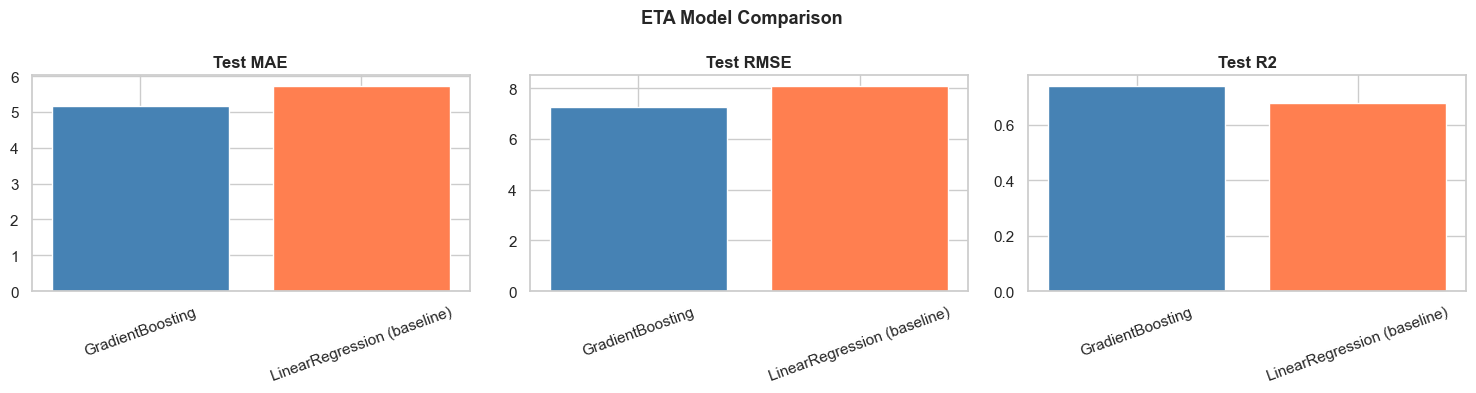

In [10]:
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
main_models = res_df[~res_df['Model'].str.startswith('Quantile')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE','RMSE','R2']):
    ax.bar(main_models['Model'], main_models[metric],
           color=['steelblue','coral','seagreen'], edgecolor='white')
    ax.set_title(f'Test {metric}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('ETA Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('../data/processed/model_comparison.png', bbox_inches='tight')
plt.show()


---
## 7. Residual Analysis — Random Forest


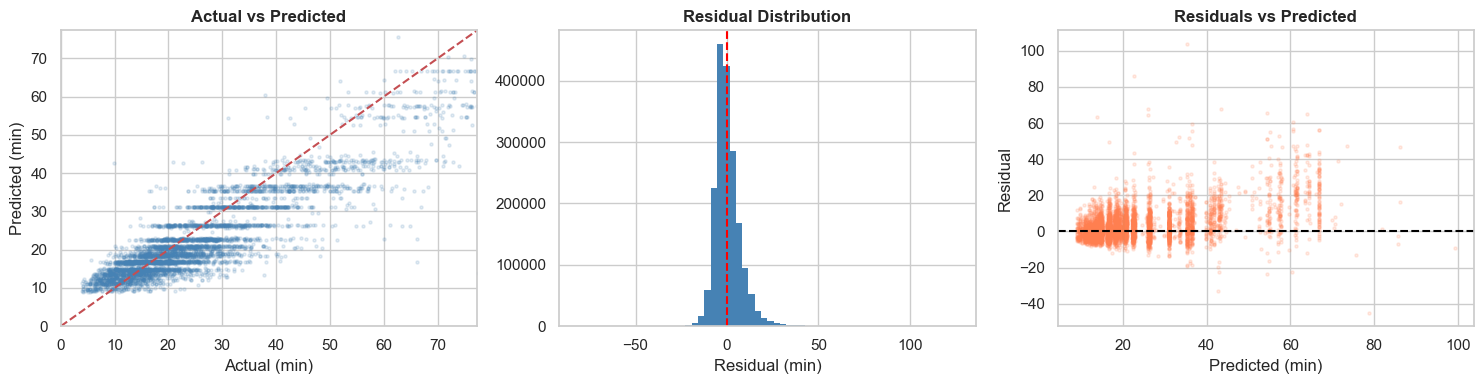

Within ±5 min : 60.5%
Within ±10 min: 88.5%


In [13]:
residuals = y_test - y_pred_rf
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lim = min(150, np.percentile(y_test, 99))
axes[0].scatter(y_test[:5000], y_pred_rf[:5000], alpha=0.15, s=5, color='steelblue')
axes[0].plot([0,lim],[0,lim],'r--',lw=1.5)
axes[0].set_xlim(0,lim); axes[0].set_ylim(0,lim)
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual (min)'); axes[0].set_ylabel('Predicted (min)')
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (min)')
axes[2].scatter(y_pred_rf[:5000], residuals[:5000], alpha=0.15, s=5, color='coral')
axes[2].axhline(0, color='black', lw=1.5, linestyle='--')
axes[2].set_title('Residuals vs Predicted', fontweight='bold')
axes[2].set_xlabel('Predicted (min)'); axes[2].set_ylabel('Residual')
plt.tight_layout(); plt.savefig('../data/processed/residuals.png', bbox_inches='tight')
plt.show()
print(f'Within ±5 min : {(np.abs(residuals)<=5).mean():.1%}')
print(f'Within ±10 min: {(np.abs(residuals)<=10).mean():.1%}')


---
## 8. Feature Importance


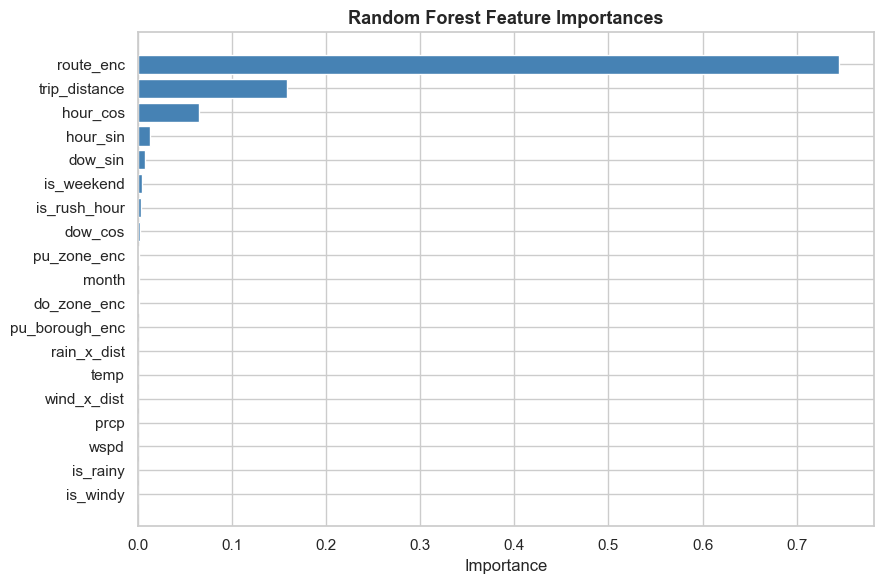

In [14]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(9,6))
plt.barh(imp.index, imp.values, color='steelblue', edgecolor='white')
plt.title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance'); plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', bbox_inches='tight')
plt.show()
